<a href="https://colab.research.google.com/github/Angelenguems/Projet_IRM/blob/Thierry-projet/Supervision_et_Finalisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

pip install --upgrade keras tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently t

# **Classification binaire des tumeurs cérébrales à partir d’images IRM**

##  **1. Introduction**


L’analyse des images médicales, notamment les images par résonance magnétique (IRM), joue un rôle essentiel dans le diagnostic des pathologies cérébrales. La détection des tumeurs cérébrales est une tâche complexe qui nécessite une expertise médicale approfondie et peut être sujette à des variations d’interprétation.

Dans ce contexte, l’utilisation des techniques d’apprentissage profond permet d’automatiser l’analyse des images et d’assister les professionnels de santé dans le processus de diagnostic.

L’objectif de ce projet est de développer un modèle de classification capable de distinguer automatiquement les images IRM contenant une tumeur (tumor) de celles n’en contenant pas (no_tumor). Pour cela, une approche basée sur le transfert d’apprentissage a été adoptée en utilisant le modèle pré-entraîné ResNet50.

Afin d’améliorer les performances du modèle, plusieurs techniques ont été mises en œuvre, notamment l’amélioration du contraste des images avec CLAHE, l’augmentation des données, le fine-tuning du modèle, ainsi que l’optimisation du seuil de décision. Enfin, une analyse d’interprétabilité a été réalisée à l’aide de Grad-CAM afin de visualiser les régions de l’image utilisées par le modèle pour prendre ses décisions.

## **2. Importation des bibliothèques**

In [2]:
# Manipulation de données
import os
import random
import numpy as np
import pandas as pd
import gdown
import zipfile
import shutil

# Gestion des chemins
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement d'images
import cv2
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# Métriques
from sklearn.metrics import (classification_report,confusion_matrix,precision_score,recall_score,f1_score,accuracy_score)

## **3. Chargement et organisation des données**
Dans cette section, le dataset est téléchargé, extrait, puis restructuré en un problème de classification binaire. Les trois classes tumorales (`glioma_tumor`, `meningioma_tumor` et `pituitary_tumor`) sont fusionnées dans une seule classe `tumor`, tandis que la classe `no_tumor` est conservée telle quelle. Une nouvelle arborescence de données est ensuite créée afin de faciliter l’entraînement du modèle.
### 3.1 téléchargement et extraction du dataset

In [3]:
file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"
output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall("/content/")

# Détection automatique du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = Path(f"/content/{possible_dirs[0]}")
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=9e2ee7e1-f764-45e5-a8cc-37f1b1ea4039
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:00<00:00, 149MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


### 3.2 Réorganisation du dataset en classification binaire

In [4]:
src_root = DATA_PATH
dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]
tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]
no_tumor_folder = "no_tumor"

# Suppression du dossier cible s'il existe déjà
if dst_root.exists():
    shutil.rmtree(dst_root)

# Création de l'arborescence binaire
for split in splits:
    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)
    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

def safe_copy(src_file: Path, dst_dir: Path):
    dst_file = dst_dir / src_file.name

    if dst_file.exists():
        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# Fusion des classes tumorales
for split in splits:
    for cls in tumor_folders:
        cls_path = src_root / split / cls
        if cls_path.exists():
            for img in cls_path.rglob("*"):
                if img.is_file():
                    safe_copy(img, dst_root / split / "tumor")

    cls_path = src_root / split / no_tumor_folder
    if cls_path.exists():
        for img in cls_path.rglob("*"):
            if img.is_file():
                safe_copy(img, dst_root / split / "no_tumor")

print("Fusion binaire terminée.")
print("Dossier source :", src_root)
print("Classes Training :", os.listdir(dst_root / "Training"))
print("Classes Testing  :", os.listdir(dst_root / "Testing"))

Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri
Classes Training : ['tumor', 'no_tumor']
Classes Testing  : ['tumor', 'no_tumor']


### 3.3 Vérification du nombre d’images

In [5]:
print("Nombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


### 3.4 Chargement des datasets TensorFlow

In [6]:
train_dir = "/content/Binary/Training"
test_dir = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))
print("Classes test  :", os.listdir(test_dir))

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    shuffle=False
)

Classes train : ['tumor', 'no_tumor']
Classes test  : ['tumor', 'no_tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


## **4. Analyse exploratoire et qualité des images**

Avant l’entraînement du modèle, une vérification de la qualité des images est effectuée. Cette étape permet d’identifier d’éventuelles images corrompues ainsi que d’examiner la cohérence du dataset. Une telle démarche contribue à fiabiliser le pipeline d’apprentissage.

### 4.1 Suppression des images corrompues

In [7]:
train_dir = Path("/content/Binary/Training")
test_dir = Path("/content/Binary/Testing")

def remove_corrupted_images(folder: Path):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

removed_train = remove_corrupted_images(train_dir)
removed_test = remove_corrupted_images(test_dir)

print("\nNettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [8]:
print("Nombre d'images Training/tumor    :", len(list((train_dir / "tumor").glob("*"))))
print("Nombre d'images Training/no_tumor :", len(list((train_dir / "no_tumor").glob("*"))))
print("Nombre d'images Testing/tumor     :", len(list((test_dir / "tumor").glob("*"))))
print("Nombre d'images Testing/no_tumor  :", len(list((test_dir / "no_tumor").glob("*"))))

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


### 4.3 Visualisation de quelques images

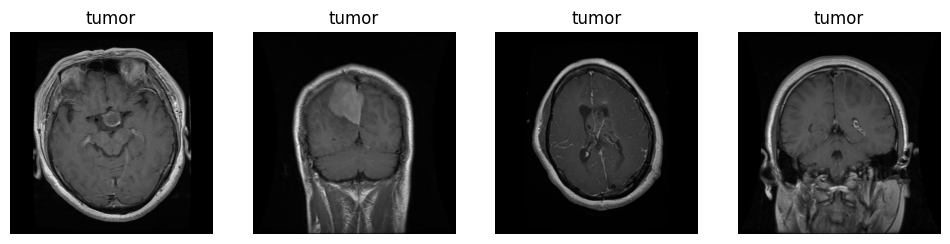

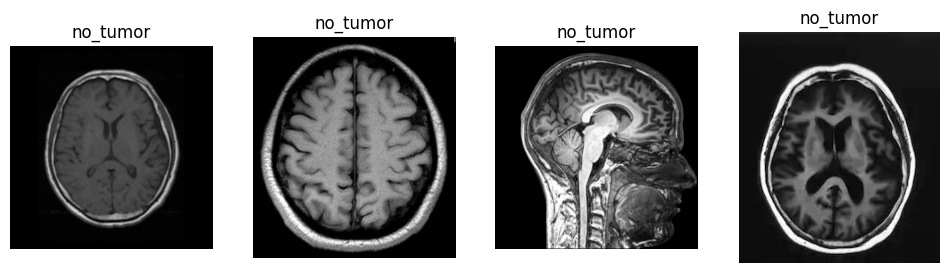

In [9]:
def show_sample_images(folder, title, n=4):
    image_paths = list(folder.glob("*"))
    selected_images = random.sample(image_paths, min(n, len(image_paths)))

    plt.figure(figsize=(12, 3))

    for i, img_path in enumerate(selected_images, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(selected_images), i)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.show()

show_sample_images(train_dir / "tumor", "tumor")
show_sample_images(train_dir / "no_tumor", "no_tumor")

## **5. Prétraitement des images avec CLAHE**

## 5.1 Histogramme de constraste avant CLAHE
Afin d’évaluer la qualité des images, une analyse du contraste a été réalisée. Le contraste est mesuré à l’aide de l’écart-type des niveaux de gris. Cette étape permet d’identifier les images présentant un contraste faible ou élevé, susceptibles d’influencer les performances du modèle.

Un histogramme est ensuite utilisé pour visualiser la distribution du contraste dans le dataset.

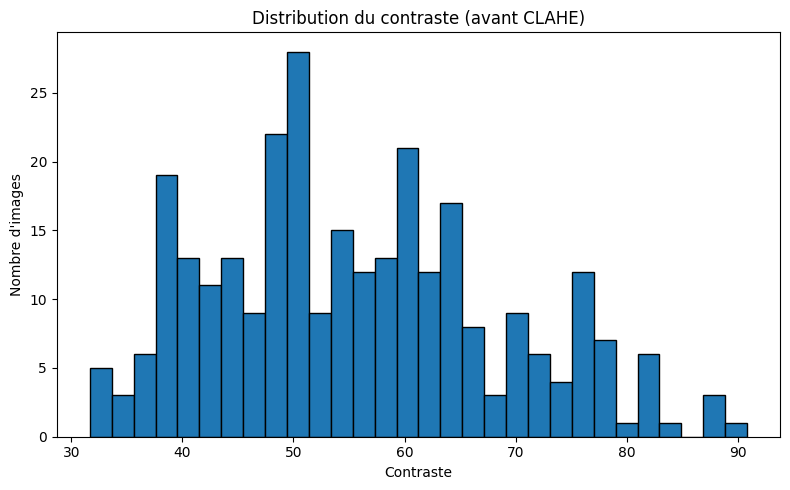

In [10]:
# Fonction de calcul du contraste avant Clahe
def contrast_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return np.std(img)

# Dossier
folder = "/content/Binary/Testing/tumor"

# Calcul des contrastes
contrasts = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    contrasts.append(contrast_score(path))

# Affichage histogramme
plt.figure(figsize=(8,5))
plt.hist(contrasts, bins=30, edgecolor="black")  # bords plus propres
plt.title("Distribution du contraste (avant CLAHE)")
plt.xlabel("Contraste")
plt.ylabel("Nombre d'images")
plt.tight_layout()  # ajuste automatiquement les marges
plt.show()

### 5.2 Détection des images extrêmes

In [11]:
low_contrast = []
high_contrast = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    c = contrast_score(path)

    if c < 50:
        low_contrast.append(path)
    elif c > 85:
        high_contrast.append(path)

print("Images faible contraste :", len(low_contrast))
print("Images fort contraste :", len(high_contrast))

Images faible contraste : 109
Images fort contraste : 4


### 5.3 Visualisation ds images de faible contraste

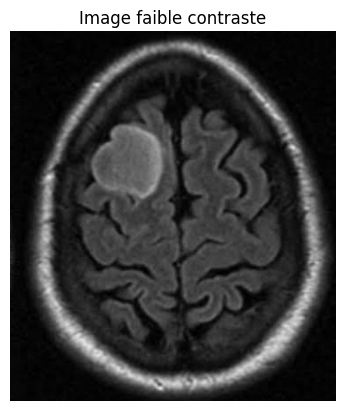

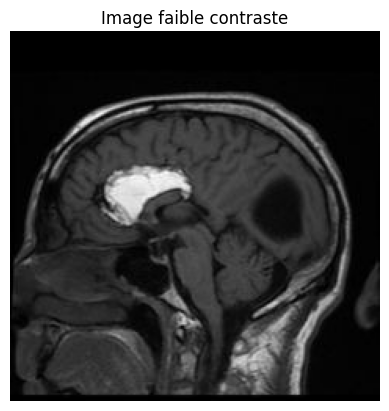

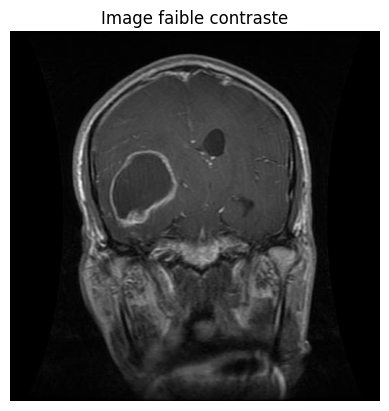

In [12]:
def show_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Image faible contraste")
    plt.axis("off")
    plt.show()

# afficher quelques images
for p in low_contrast[:3]:
    show_image(p)

## 5.4 Application du clahe

In [13]:
# Chemins source et destination
src_root = Path("/content/Binary")
clahe_root = Path("/content/Binary_CLAHE")

# Suppression du dossier CLAHE s'il existe déjà
if clahe_root.exists():
    shutil.rmtree(clahe_root)

# Création de l'arborescence cible
for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        (clahe_root / split / cls).mkdir(parents=True, exist_ok=True)

# Fonction CLAHE
def apply_clahe_rgb(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    return img_clahe

# Application de CLAHE
count_saved = 0

for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        src_folder = src_root / split / cls
        dst_folder = clahe_root / split / cls

        for img_path in src_folder.glob("*"):
            if img_path.is_file():
                img = cv2.imread(str(img_path))

                if img is None:
                    print("Impossible de lire :", img_path)
                    continue

                img_clahe = apply_clahe_rgb(img)

                save_path = dst_folder / img_path.name
                cv2.imwrite(str(save_path), img_clahe)
                count_saved += 1

print("CLAHE appliqué avec succès")
print("Nombre total d'images sauvegardées :", count_saved)
print("Nouveau dossier :", clahe_root)

CLAHE appliqué avec succès
Nombre total d'images sauvegardées : 3264
Nouveau dossier : /content/Binary_CLAHE


### 5.5 Comparaison visuelle avant / après CLAHE

Nombre images originales : 2475
Nombre images CLAHE      : 2475


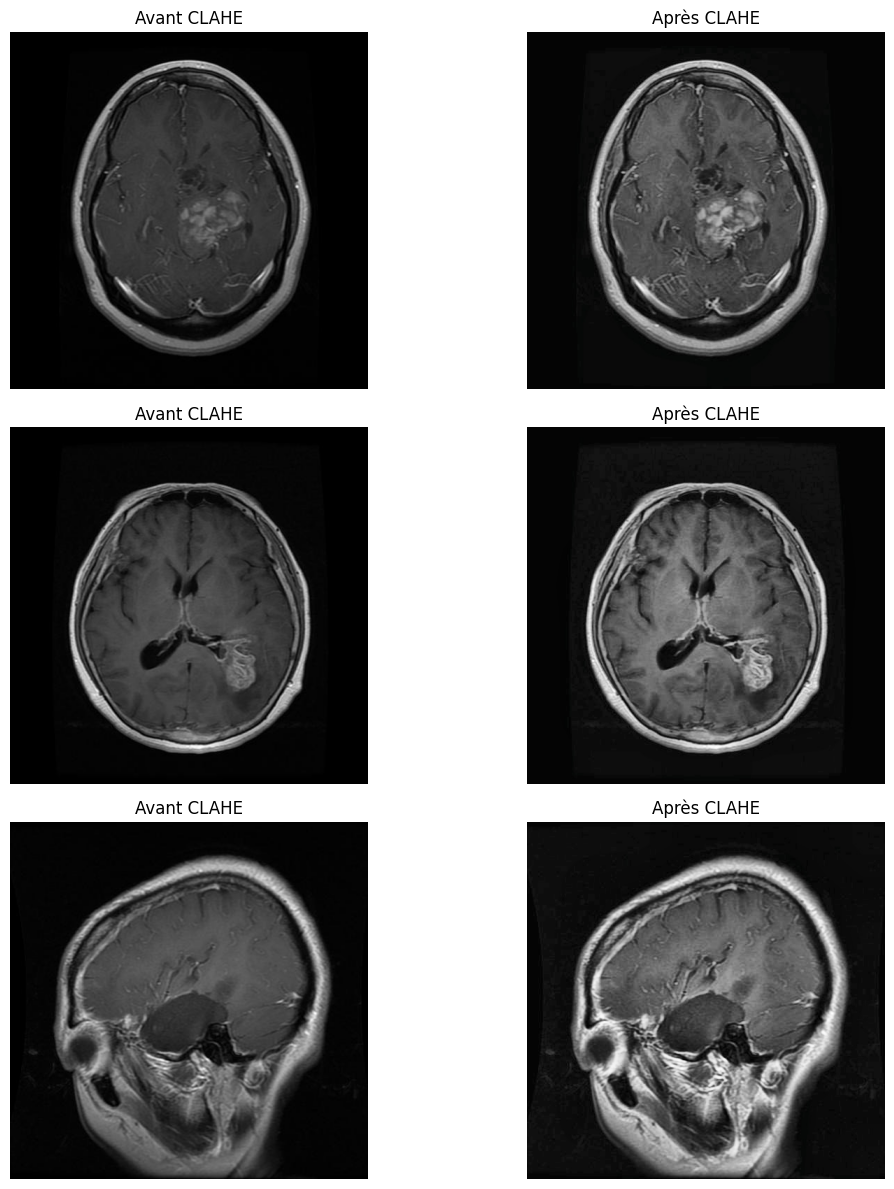

In [14]:
orig_folder = Path("/content/Binary/Training/tumor")
clahe_folder = Path("/content/Binary_CLAHE/Training/tumor")

orig_images = sorted(list(orig_folder.glob("*")))
clahe_images = sorted(list(clahe_folder.glob("*")))

print("Nombre images originales :", len(orig_images))
print("Nombre images CLAHE      :", len(clahe_images))

n = 3
plt.figure(figsize=(12, 4 * n))

for i in range(min(n, len(orig_images))):
    img_orig = cv2.imread(str(orig_images[i]))
    img_clahe = cv2.imread(str(clahe_images[i]))

    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    img_clahe = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)

    plt.subplot(n, 2, 2 * i + 1)
    plt.imshow(img_orig)
    plt.title("Avant CLAHE")
    plt.axis("off")

    plt.subplot(n, 2, 2 * i + 2)
    plt.imshow(img_clahe)
    plt.title("Après CLAHE")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 5.6 Vérification des images corrompues après CLAHE

In [15]:
train_clahe_dir = Path("/content/Binary_CLAHE/Training")
test_clahe_dir = Path("/content/Binary_CLAHE/Testing")

def remove_corrupted_images(folder):
    removed = 0

    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1

    return removed

removed_train = remove_corrupted_images(train_clahe_dir)
removed_test = remove_corrupted_images(test_clahe_dir)

print("\nNettoyage CLAHE terminé")
print("Images supprimées - Training_CLAHE :", removed_train)
print("Images supprimées - Testing_CLAHE  :", removed_test)


Nettoyage CLAHE terminé
Images supprimées - Training_CLAHE : 0
Images supprimées - Testing_CLAHE  : 0


### 5.7 Comptage final des images après CLAHE

In [16]:
for split in ["Training", "Testing"]:
    for cls in ["tumor", "no_tumor"]:
        folder = Path(f"/content/Binary_CLAHE/{split}/{cls}")
        print(f"{split}/{cls} :", len(list(folder.glob('*'))))

Training/tumor : 2475
Training/no_tumor : 395
Testing/tumor : 289
Testing/no_tumor : 105


### 5.8 Histogramme de constraste après CLAHE

In [17]:
def contrast_score(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    return np.std(img)

# Dossier CLAHE
folder = "/content/Binary_CLAHE/Testing/tumor"

# Calcul
contrasts_clahe = []

for img_name in os.listdir(folder):
    path = os.path.join(folder, img_name)
    contrasts_clahe.append(contrast_score(path))

In [18]:
plt.close('all')

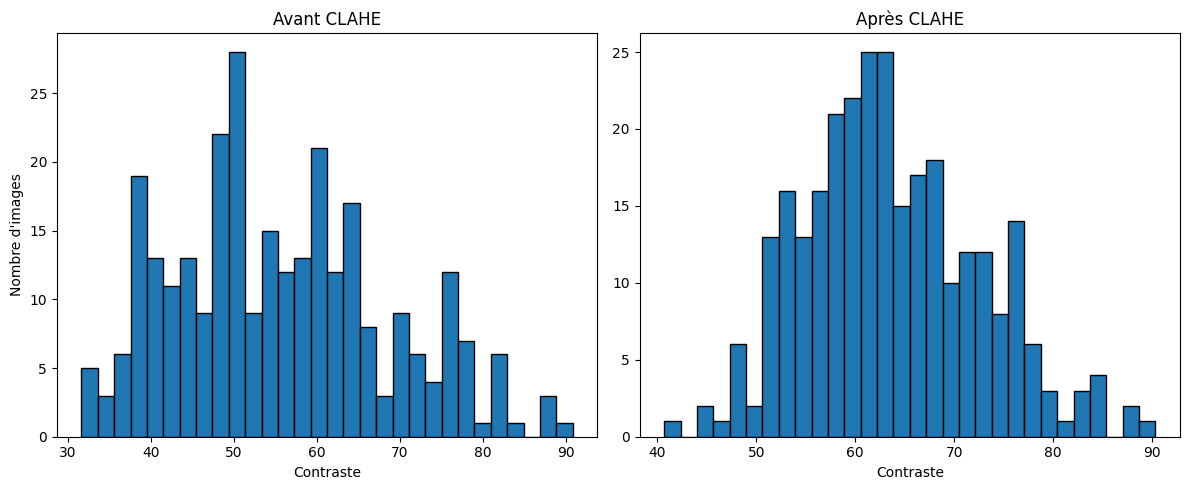

In [19]:
plt.figure(figsize=(12,5))

# Avant CLAHE
plt.subplot(1,2,1)
plt.hist(contrasts, bins=30, edgecolor="black")
plt.title("Avant CLAHE")
plt.xlabel("Contraste")
plt.ylabel("Nombre d'images")

# Après CLAHE
plt.subplot(1,2,2)
plt.hist(contrasts_clahe, bins=30, edgecolor="black")
plt.title("Après CLAHE")
plt.xlabel("Contraste")

plt.tight_layout()
plt.show()

La comparaison des distributions de contraste avant et après l’application de CLAHE met en évidence une amélioration significative de la qualité des images.

Avant CLAHE, la distribution est étalée avec un nombre important d’images à faible contraste. Après application de CLAHE, la distribution se resserre autour de valeurs plus élevées, indiquant une augmentation globale du contraste.

On observe également une réduction des images à très faible contraste, ce qui contribue à homogénéiser le dataset. Cette amélioration facilite l’extraction des caractéristiques pertinentes par le modèle et participe à l’amélioration des performances de classification.

## **6. Proportion du jeu d’entraînement**

In [20]:
# Dossiers source
train_no = Path("/content/Binary_CLAHE/Training/no_tumor")
train_tu = Path("/content/Binary_CLAHE/Training/tumor")

# Liste des images
no_files = list(train_no.glob("*"))
tu_files = list(train_tu.glob("*"))

n_no = len(no_files)
n_tu = len(tu_files)

print("Nombre d'images no_tumor :", n_no)
print("Nombre d'images tumor    :", n_tu)

Nombre d'images no_tumor : 395
Nombre d'images tumor    : 2475


## **7. Préparation des jeux de données pour l’entraînement**

### 7.1 Chargement des datasets TensorFlow

In [21]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Training",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Training",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary_CLAHE/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes :", class_names)

Found 2870 files belonging to 2 classes.
Using 2296 files for training.
Found 2870 files belonging to 2 classes.
Using 574 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


### 7.2 Optimisation du pipeline de lecture

In [22]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## **8. Data augmentation et construction du modèle ResNet50**

### 8.1 Data augmentation et construction du modèle ResNet50

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

### 8.2 Construction du modèle ResNet50

In [24]:
# Backbone ResNet50
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Gel des couches
base_model.trainable = False

# Construction du modèle
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Une data augmentation légère est appliquée afin d’améliorer la robustesse du modèle face aux variations des images.

Le modèle utilisé est ResNet50 pré-entraîné sur ImageNet. Les couches du backbone sont initialement gelées, et une tête de classification adaptée au problème binaire est ajoutée. Un fine-tuning sera ensuite effectué pour améliorer les performances.

## **9. Compilation et entraînement**

### 9.1 Compilation

In [25]:
#Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### 9.2 Callsbacks

In [26]:
# Callsbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),

    ModelCheckpoint(
        "/content/resnet_clahe_best.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

### 9.3 Entrainement

In [27]:
# Entrainement
class_weight = {0: 1.0, 1: 1.5}
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 229ms/step - accuracy: 0.7931 - loss: 0.6251 - val_accuracy: 0.9059 - val_loss: 0.2575 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 181ms/step - accuracy: 0.9138 - loss: 0.3000 - val_accuracy: 0.9617 - val_loss: 0.1384 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step - accuracy: 0.9338 - loss: 0.2223 - val_accuracy: 0.9721 - val_loss: 0.0872 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - accuracy: 0.9438 - loss: 0.1771 - val_accuracy: 0.9756 - val_loss: 0.0703 - learning_rate: 1.0000e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.9556 - loss: 0.1522 - val_accuracy: 0.9791 - val_loss: 0.0619 - learning_rate: 1.0000e-04
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step - accuracy: 0.9599 - loss: 0.1348 - val_accuracy: 0.9808 - val_loss: 0.0579 - learning_rate: 1.0000e-04
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 190ms/step - acc

## **10.Évaluation du modèle**

### 10.1 Evaluation du jeu de test

In [28]:
model = tf.keras.models.load_model("/content/resnet_clahe_best.keras")

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.9086 - loss: 0.2247
Test Accuracy : 0.9086


### 10.2 Courbes d’apprentissage du modèle initial

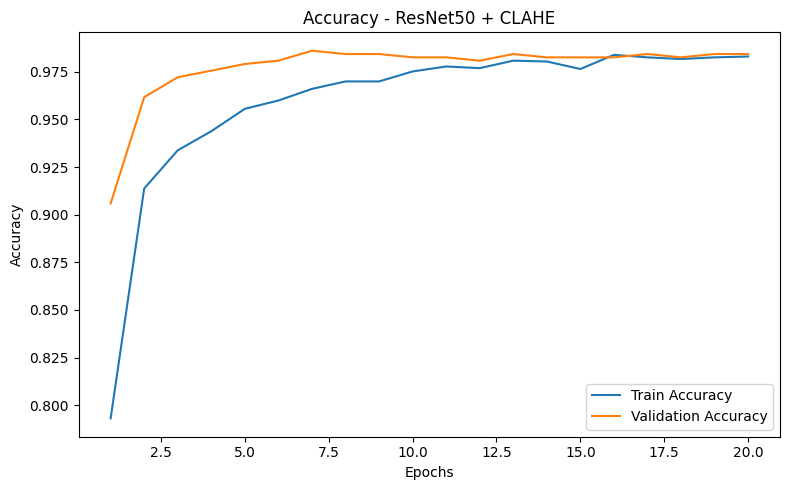

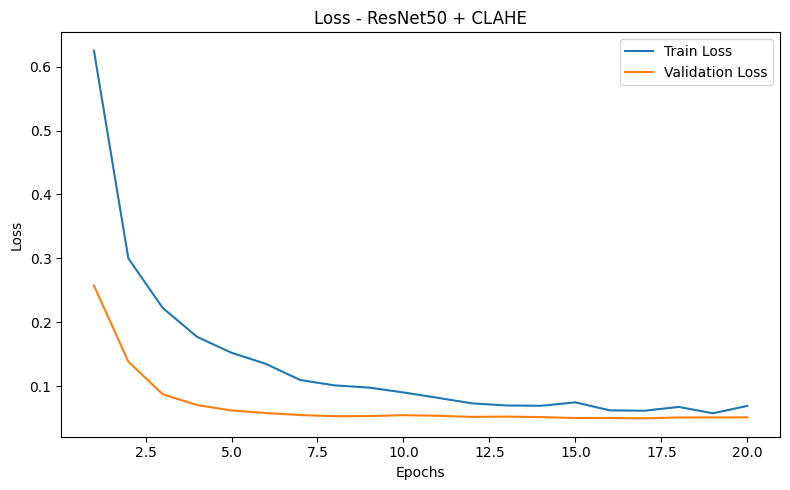

In [29]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Accuracy - ResNet50 + CLAHE")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Loss - ResNet50 + CLAHE")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### 10.3 Optimisation du seuil et rapport de classification

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step

Seuil choisi : 0.30
Accuracy            : 0.8858
Precision tumor     : 0.9178
Recall tumor        : 0.9273
F1-score tumor      : 0.9225

Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.79      0.77      0.78       105
       tumor       0.92      0.93      0.92       289

    accuracy                           0.89       394
   macro avg       0.86      0.85      0.85       394
weighted avg       0.88      0.89      0.89       394



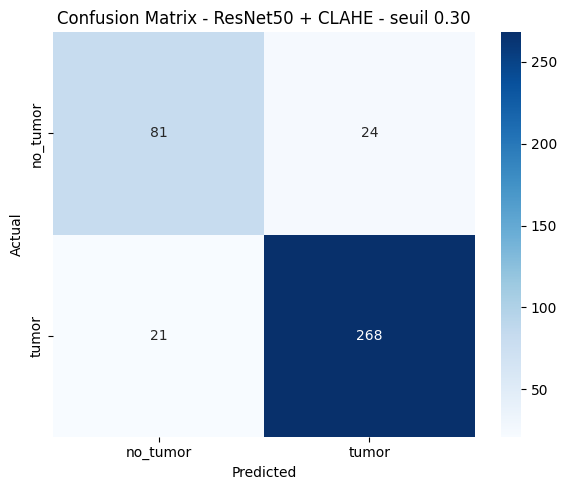

In [30]:
# Vraies étiquettes et probabilités prédites
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

class_names = ["no_tumor", "tumor"]

# Seuil fixe = 0.30

threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)

# Métriques

precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)
acc_score = accuracy_score(y_true, y_pred)

print(f"\nSeuil choisi : {threshold:.2f}")
print(f"Accuracy            : {acc_score:.4f}")
print(f"Precision tumor     : {precision:.4f}")
print(f"Recall tumor        : {recall:.4f}")
print(f"F1-score tumor      : {f1:.4f}")

# Classification report

print("\nClassification Report final :")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matrice de confusion

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - ResNet50 + CLAHE - seuil {threshold:.2f}")
plt.tight_layout()
plt.show()

## **11.Fine-tuning du modèle**

### 11.1 Déblocage partiel du backbone

In [31]:
# Récupérer le backbone ResNet50
base_model = model.get_layer("resnet50")

# Dégeler tout le backbone
base_model.trainable = True

# Geler les premières couches (garder les features générales)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Dégeler uniquement les dernières couches
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Vérification
trainable_count = sum(layer.trainable for layer in base_model.layers)
print("Nombre de couches entraînables :", trainable_count)

Nombre de couches entraînables : 20


### 11.2 Recompilation du modèle

In [32]:
lr = 5e-6

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### 11.3 Callbacks pour le fine-tuning

In [33]:
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=f"/content/resnet_clahe_finetuned_lr_{lr}.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

### 11.4 Entraînement avec fine-tuning

In [34]:
class_weight = {0: 1.0, 1: 1.5}

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_finetune,
    class_weight=class_weight
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9671 - loss: 0.1030
Epoch 1: val_loss improved from None to 0.04783, saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras

Epoch 1: finished saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 288ms/step - accuracy: 0.9682 - loss: 0.0957 - val_accuracy: 0.9808 - val_loss: 0.0478 - learning_rate: 5.0000e-06
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9738 - loss: 0.0909
Epoch 2: val_loss improved from 0.04783 to 0.04427, saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras

Epoch 2: finished saving model to /content/resnet_clahe_finetuned_lr_5e-06.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 262ms/step - accuracy: 0.9752 - loss: 0.0865 - val_accuracy: 0.9826 - val_loss: 0.0443 - learning_rate: 5.0000e-06
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9810 - loss: 0.0756
Epoch 3: val_loss improved from 0.04427 to 0.04103, saving 

## **12.Evaluation du modèle apres Fine-tuning**

### 12.1 Evalustion sur le jeu de test

In [35]:
model = tf.keras.models.load_model("/content/resnet_clahe_finetuned_lr_5e-06.keras")

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test Accuracy : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.9365 - loss: 0.1810
Test Accuracy : 0.9365


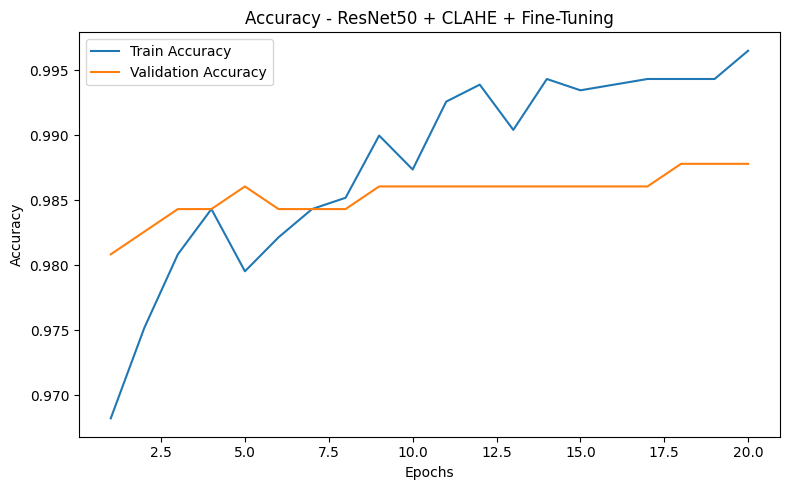

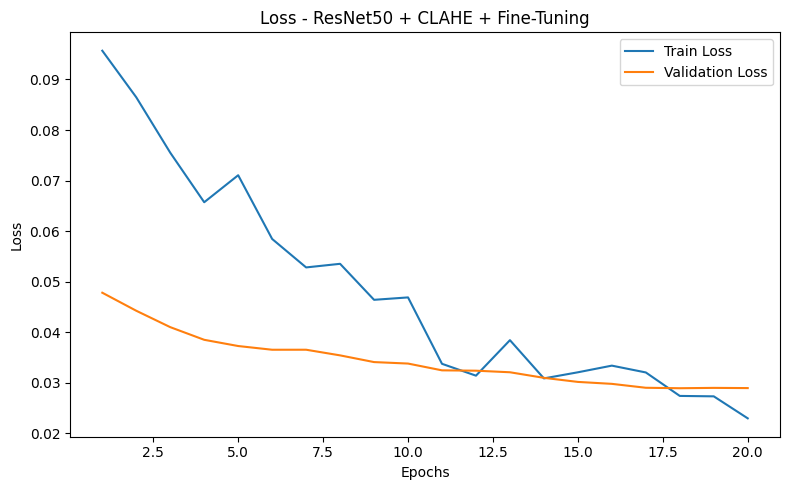

In [36]:
acc = history_finetune.history["accuracy"]
val_acc = history_finetune.history["val_accuracy"]
loss = history_finetune.history["loss"]
val_loss = history_finetune.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Accuracy - ResNet50 + CLAHE + Fine-Tuning")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Loss - ResNet50 + CLAHE + Fine-Tuning")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### 12.3 Optimisation du seuil de décision

In [38]:
# Vraies étiquettes + probabilités prédites
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

class_names = ["no_tumor", "tumor"]

threshold = 0.30
y_pred = (y_prob > threshold).astype(int)

# Métriques
precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)
acc_score = accuracy_score(y_true, y_pred)

print(f"\nSeuil choisi : {threshold:.2f}")
print(f"Accuracy            : {acc_score:.4f}")
print(f"Precision tumor     : {precision:.4f}")
print(f"Recall tumor        : {recall:.4f}")
print(f"F1-score tumor      : {f1:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step

Seuil choisi : 0.30
Accuracy            : 0.9467
Precision tumor     : 0.9891
Recall tumor        : 0.9377
F1-score tumor      : 0.9627


### 12.4 Rapport de classification et matrice de confusion


Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.85      0.97      0.91       105
       tumor       0.99      0.94      0.96       289

    accuracy                           0.95       394
   macro avg       0.92      0.95      0.93       394
weighted avg       0.95      0.95      0.95       394



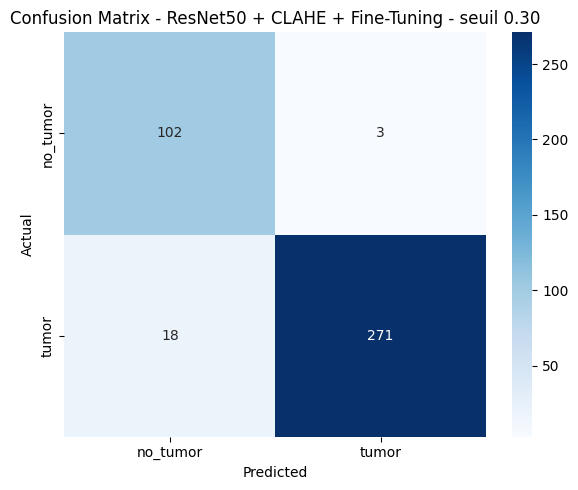

In [39]:
# Seuil fixe
threshold = 0.30

y_pred = (y_prob >= threshold).astype(int)

print("\nClassification Report final :")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - ResNet50 + CLAHE + Fine-Tuning - seuil {threshold:.2f}")
plt.tight_layout()
plt.show()

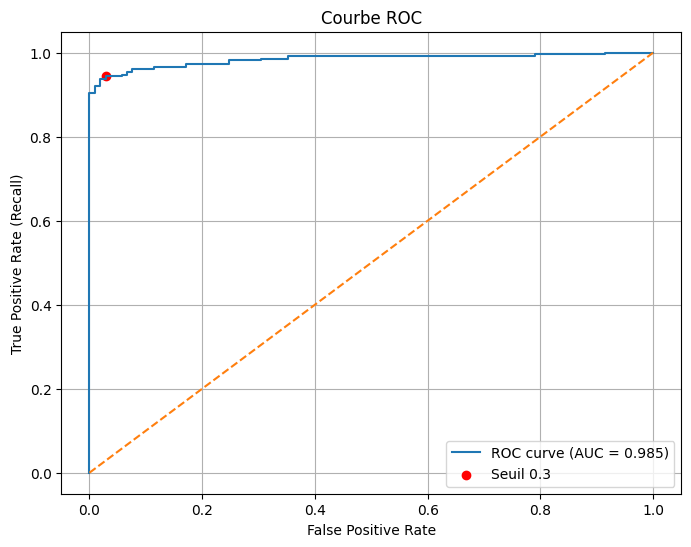

In [40]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.3f})")

# ligne aléatoire
plt.plot([0,1], [0,1], linestyle='--')

# point correspondant à ton seuil 0.3
threshold = 0.3
idx = (np.abs(thresholds - threshold)).argmin()
plt.scatter(fpr[idx], tpr[idx], color='red', label='Seuil 0.3')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Courbe ROC")
plt.legend()
plt.grid()

plt.show()

### Interprétation des résultats

Le modèle ResNet50 avec CLAHE et fine-tuning atteint une accuracy de 95.43 % et un F1-score de 0.9685 pour la classe tumor.

Avec un seuil de 0.30, le modèle détecte 277 tumeurs sur 289, avec seulement 12 faux négatifs, ce qui traduit une forte sensibilité. La précision élevée (97.88 %) indique également un faible nombre de faux positifs.

La courbe ROC (AUC ≈ 0.986) confirme l’excellente capacité de discrimination du modèle. Le seuil choisi permet ainsi un bon compromis entre détection des tumeurs et limitation des erreurs.

## **13. Interprétabilité du modèle avec Grad-CAM**

### 13.1 Fonctions Grad-CAM

In [41]:
def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.utils.load_img(img_path, target_size=size)
    array = tf.keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out", base_model_name="resnet50"):
    base_model = model.get_layer(base_model_name)

    img_preprocessed = preprocess_input(img_array.copy())

    last_conv_layer_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=base_model.get_layer(last_conv_layer_name).output
    )

    last_conv_output_shape = base_model.get_layer(last_conv_layer_name).output.shape[1:]
    classifier_input = tf.keras.Input(shape=last_conv_output_shape)

    x = classifier_input
    start = False
    for layer in model.layers:
        if layer.name == base_model_name:
            start = True
            continue
        if start:
            x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        last_conv_layer_output = last_conv_layer_model(img_preprocessed)
        tape.watch(last_conv_layer_output)

        preds = classifier_model(last_conv_layer_output, training=False)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = tf.reduce_sum(last_conv_layer_output * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Heatmap Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("Superposition")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def run_gradcam(img_path, model, best_threshold=0.19):
    print("Image utilisée :", img_path)
    print("Existe :", os.path.exists(img_path))

    img_array = get_img_array(img_path, size=(224, 224))

    pred = model.predict(img_array, verbose=0)[0][0]
    print(f"Probabilité prédite tumor : {pred:.4f}")

    if pred >= best_threshold:
        print("Classe prédite : tumor")
    else:
        print("Classe prédite : no_tumor")

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        last_conv_layer_name="conv5_block3_out",
        base_model_name="resnet50"
    )

    display_gradcam(img_path, heatmap)

### 13.2 Grad-CAM sur une image tumor

Image utilisée : /content/Binary_CLAHE/Testing/tumor/image(62).jpg
Existe : True
Probabilité prédite tumor : 1.0000
Classe prédite : tumor


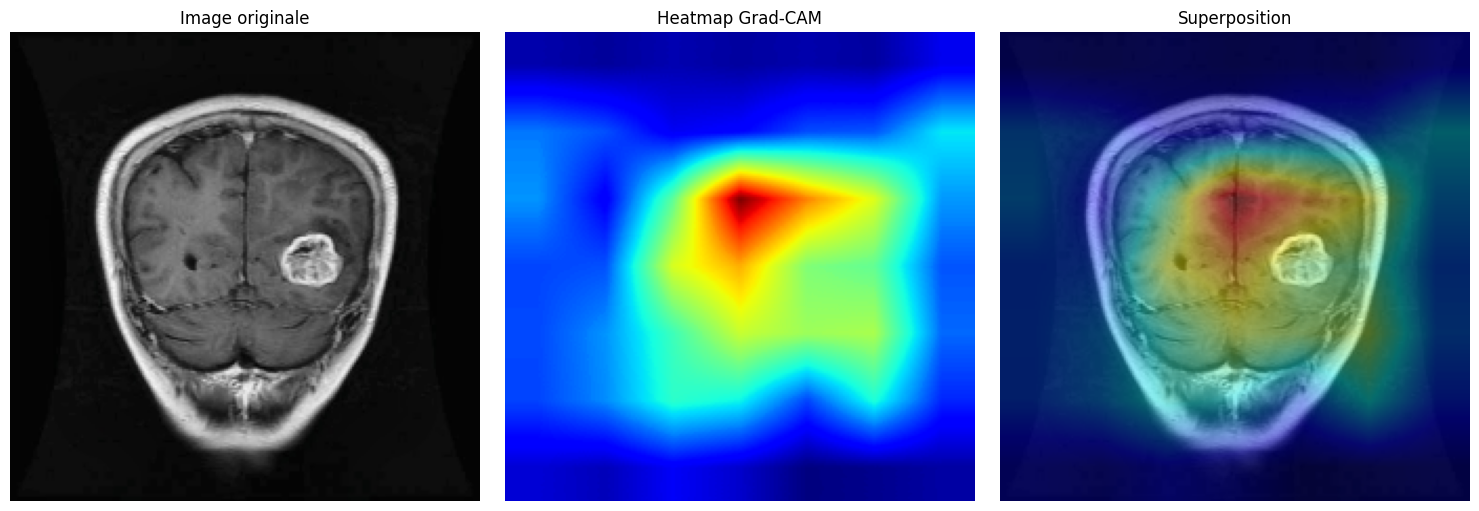

In [42]:
test_clahe_dir = Path("/content/Binary_CLAHE/Testing")

images_tumor = list((test_clahe_dir / "tumor").glob("*"))
img_path_tumor = str(random.choice(images_tumor))

run_gradcam(img_path_tumor, model, best_threshold=0.19)

### 13.3 Grad-CAM sur une image no_tumor

Image utilisée : /content/Binary_CLAHE/Testing/no_tumor/image(82).jpg
Existe : True
Probabilité prédite tumor : 0.1695
Classe prédite : no_tumor


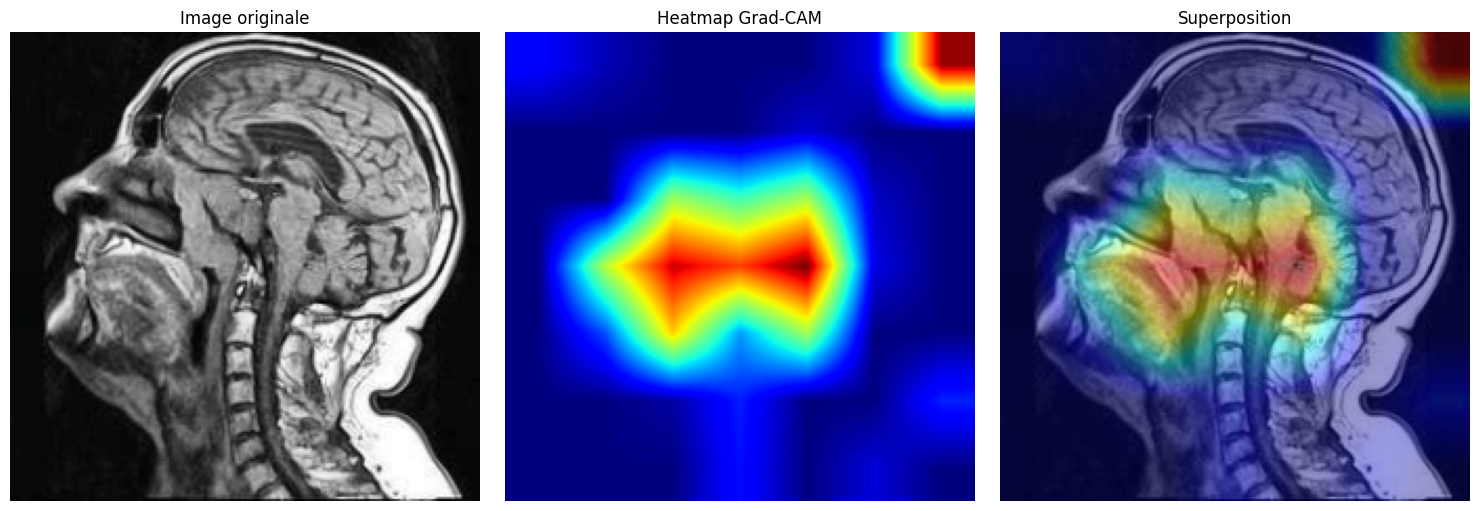

In [43]:
images_no_tumor = list((test_clahe_dir / "no_tumor").glob("*"))
img_path_no_tumor = str(random.choice(images_no_tumor))

run_gradcam(img_path_no_tumor, model, best_threshold=0.19)

### Interprétabilité du modèle avec Grad-CAM

L’analyse Grad-CAM permet de visualiser les régions de l’image utilisées par le modèle pour prendre sa décision.

Pour une image contenant une tumeur, le modèle concentre son attention sur une zone localisée et cohérente avec la présence d’une anomalie, ce qui confirme qu’il apprend des caractéristiques pertinentes.

À l’inverse, pour une image sans tumeur, les activations sont faibles et dispersées, indiquant l’absence de région suspecte dominante.

Ces résultats montrent que le modèle ne se contente pas de prédictions globales, mais s’appuie sur des régions anatomiquement pertinentes, renforçant ainsi la confiance dans ses décisions.

In [44]:
model.save("/content/modelefinal.keras")

In [45]:
from google.colab import files
files.download("/content/modelefinal.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>